In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_excel(r"C:\Users\vinaykumar\Downloads\SELL BACK DATASET.xlsx")

In [3]:
df

,timestamp,season,cloud_cover,day_type,hour,GHI_W_m2,solar_generation_kWh,household_demand_kWh,net_energy_kWh,battery_capacity_kWh,battery_level_kWh,grid_demand_kWh,electricity_price
0,2024-01-01 00:00:00,Winter,48,Weekday,0,0.0,0.0,0.4,0.0,20,6,12,2.81351
1,2024-01-01 01:00:00,Winter,41,Weekday,1,0.0,0.0,0.4,0.0,20,6,12,2.48937
2,2024-01-01 02:00:00,Winter,40,Weekday,2,0.0,0.0,0.4,0.0,20,6,12,2.34995
3,2024-01-01 03:00:00,Winter,40,Weekday,3,0.0,0.0,0.4,0.0,20,6,12,2.42490
4,2024-01-01 04:00:00,Winter,43,Weekday,4,0.0,0.0,0.4,0.0,20,6,12,2.44748
...,...,...,...,...,...,...,...,...,...,...,...,...,...
17539,2025-12-31 19:00:00,Winter,87,Weekday,19,0.0,0.0,3.0,0.0,20,10,35,7.61391
17540,2025-12-31 20:00:00,Winter,72,Weekday,20,0.0,0.0,3.0,0.0,20,10,35,4.47728
17541,2025-12-31 21:00:00,Winter,53,Weekday,21,0.0,0.0,3.0,0.0,20,10,35,4.10381
17542,2025-12-31 22:00:00,Winter,46,Weekday,22,0.0,0.0,3.0,0.0,20,10,35,3.73799


In [4]:
df['electricity_price'].describe()

count    17544.000000
mean         4.289622
std          2.602802
min          0.049560
25%          2.695922
50%          3.429970
75%          4.752615
max         10.000000
Name: electricity_price, dtype: float64

In [5]:
df_1 = df.copy()

In [6]:
df.columns

Index(['timestamp', 'season', 'cloud_cover', 'day_type', 'hour', 'GHI_W_m2',
       'solar_generation_kWh', 'household_demand_kWh', 'net_energy_kWh',
       'battery_capacity_kWh', 'battery_level_kWh', 'grid_demand_kWh',
       'electricity_price'],
      dtype='object')

In [7]:
df['season'].unique()

array(['Winter', 'Summer', 'Monsoon'], dtype=object)

In [8]:
df['day_type'].unique()

array(['Weekday', 'Weekend'], dtype=object)

In [9]:
df_1

,timestamp,season,cloud_cover,day_type,hour,GHI_W_m2,solar_generation_kWh,household_demand_kWh,net_energy_kWh,battery_capacity_kWh,battery_level_kWh,grid_demand_kWh,electricity_price
0,2024-01-01 00:00:00,Winter,48,Weekday,0,0.0,0.0,0.4,0.0,20,6,12,2.81351
1,2024-01-01 01:00:00,Winter,41,Weekday,1,0.0,0.0,0.4,0.0,20,6,12,2.48937
2,2024-01-01 02:00:00,Winter,40,Weekday,2,0.0,0.0,0.4,0.0,20,6,12,2.34995
3,2024-01-01 03:00:00,Winter,40,Weekday,3,0.0,0.0,0.4,0.0,20,6,12,2.42490
4,2024-01-01 04:00:00,Winter,43,Weekday,4,0.0,0.0,0.4,0.0,20,6,12,2.44748
...,...,...,...,...,...,...,...,...,...,...,...,...,...
17539,2025-12-31 19:00:00,Winter,87,Weekday,19,0.0,0.0,3.0,0.0,20,10,35,7.61391
17540,2025-12-31 20:00:00,Winter,72,Weekday,20,0.0,0.0,3.0,0.0,20,10,35,4.47728
17541,2025-12-31 21:00:00,Winter,53,Weekday,21,0.0,0.0,3.0,0.0,20,10,35,4.10381
17542,2025-12-31 22:00:00,Winter,46,Weekday,22,0.0,0.0,3.0,0.0,20,10,35,3.73799


In [10]:
# Convert timestamp
df_1['timestamp'] = pd.to_datetime(df_1['timestamp'])
df_1 = df_1.sort_values(by='timestamp')

#  Encode season
season_map = {'Winter': 0, 'Summer': 1, 'Monsoon': 2}
df_1['season'] = df_1['season'].map(season_map)

#  Encode day_type
day_map = {'Weekday': 0, 'Weekend': 1}
df_1['day_type'] = df_1['day_type'].map(day_map)

In [11]:
df_1

,timestamp,season,cloud_cover,day_type,hour,GHI_W_m2,solar_generation_kWh,household_demand_kWh,net_energy_kWh,battery_capacity_kWh,battery_level_kWh,grid_demand_kWh,electricity_price
0,2024-01-01 00:00:00,0,48,0,0,0.0,0.0,0.4,0.0,20,6,12,2.81351
1,2024-01-01 01:00:00,0,41,0,1,0.0,0.0,0.4,0.0,20,6,12,2.48937
2,2024-01-01 02:00:00,0,40,0,2,0.0,0.0,0.4,0.0,20,6,12,2.34995
3,2024-01-01 03:00:00,0,40,0,3,0.0,0.0,0.4,0.0,20,6,12,2.42490
4,2024-01-01 04:00:00,0,43,0,4,0.0,0.0,0.4,0.0,20,6,12,2.44748
...,...,...,...,...,...,...,...,...,...,...,...,...,...
17539,2025-12-31 19:00:00,0,87,0,19,0.0,0.0,3.0,0.0,20,10,35,7.61391
17540,2025-12-31 20:00:00,0,72,0,20,0.0,0.0,3.0,0.0,20,10,35,4.47728
17541,2025-12-31 21:00:00,0,53,0,21,0.0,0.0,3.0,0.0,20,10,35,4.10381
17542,2025-12-31 22:00:00,0,46,0,22,0.0,0.0,3.0,0.0,20,10,35,3.73799


In [12]:
features = ['season', 'hour', 'day_type', '']
target = 'electricity_price'

X = df_1[features]
y = df_1[target]

In [13]:
train = df_1[df_1['timestamp'].dt.year == 2025]

In [14]:
future_dates = pd.date_range(start='2026-01-01', end='2026-01-07 23:00', freq='H')

future_df = pd.DataFrame({'timestamp': future_dates})

# Hour
future_df['hour'] = future_df['timestamp'].dt.hour

# Day type
future_df['day_type'] = future_df['timestamp'].dt.weekday.apply(lambda x: 1 if x >= 5 else 0)

# Season (Jan → Winter)
future_df['season'] = 0

# Grid demand (simple assumption → use last known pattern)
future_df['grid_demand_kWh'] = df_1['grid_demand_kWh'].tail(len(future_df)).values

C:\Users\vinaykumar\AppData\Local\Temp\ipykernel_5300\1818797056.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  future_dates = pd.date_range(start='2026-01-01', end='2026-01-07 23:00', freq='H')


In [15]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

X_train = train[features]
y_train = train[target]

model_sarimax = SARIMAX(
    y_train,
    exog=X_train,
    order=(1,1,1),
    seasonal_order=(1,1,1,24)
)

model_fit = model_sarimax.fit()

forecast_sarimax = model_fit.forecast(
    steps=len(future_df),
    exog=future_df[features]
)

C:\Users\vinaykumar\Desktop\jupyter\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\vinaykumar\Desktop\jupyter\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\vinaykumar\Desktop\jupyter\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
C:\Users\vinaykumar\Desktop\jupyter\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check ml

In [16]:
future_df['SARIMAX'] = forecast_sarimax.values

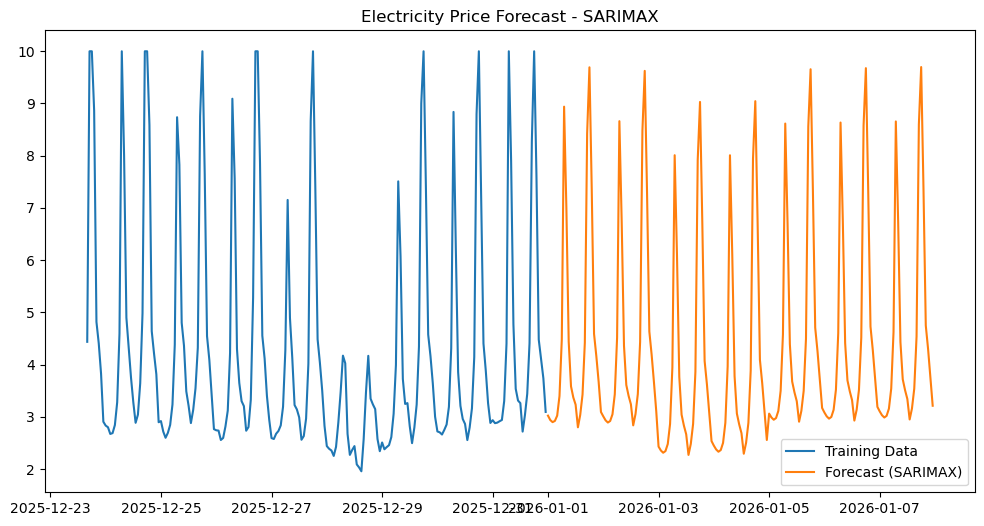

In [17]:
# Last part of training data (for visualization)
train_plot = train.set_index('timestamp')[target].iloc[-200:]

# Create future datetime index
future_index = future_df['timestamp']

# -----------------------------
#  2. SARIMAX Plot
# -----------------------------
plt.figure(figsize=(12,6))

plt.plot(train_plot, label="Training Data")
plt.plot(future_index, future_df['SARIMAX'], label="Forecast (SARIMAX)")

plt.title("Electricity Price Forecast - SARIMAX")
plt.legend()
plt.show()

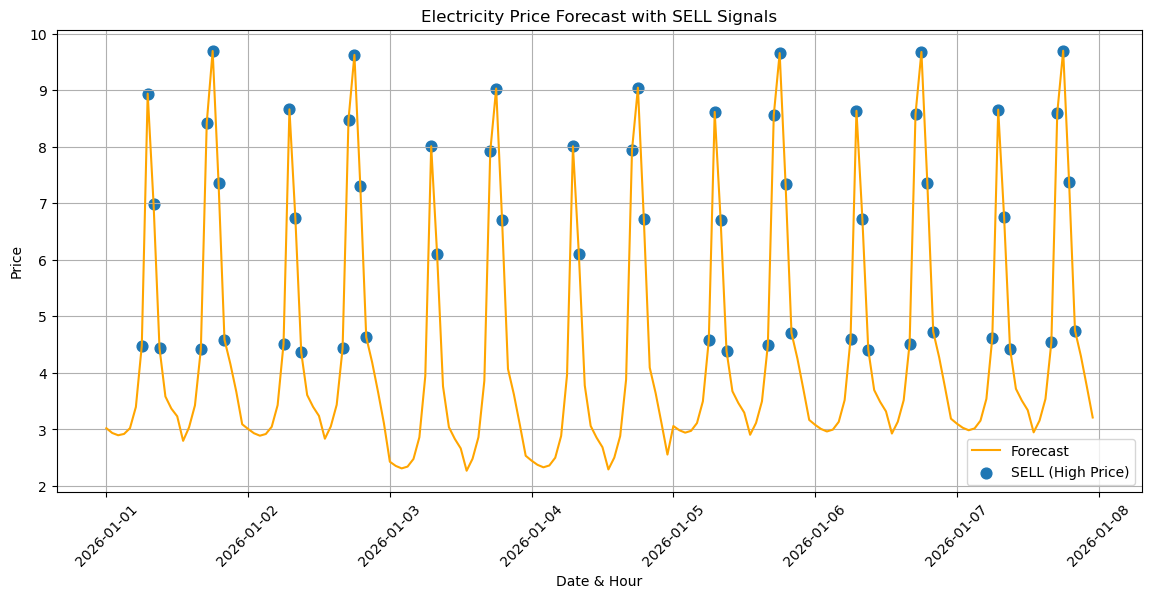

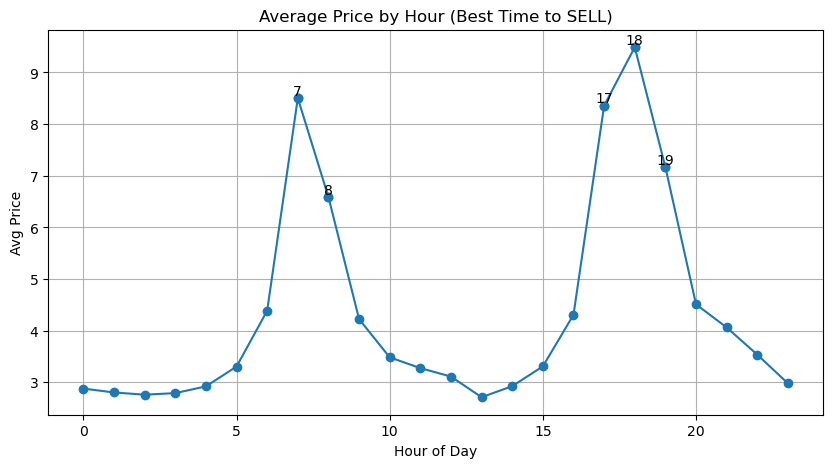


⚡ BEST HOURS TO SELL (Highest Price):
hour
18    9.488949
7     8.503742
17    8.358224
19    7.166491
8     6.587691
Name: SARIMAX, dtype: float64


In [18]:
import numpy as np

# -----------------------------
# Add hour column
# -----------------------------
future_df['hour'] = future_df['timestamp'].dt.hour

# -----------------------------
# 1. Highlight HIGH PRICE ZONES
# -----------------------------
threshold = future_df['SARIMAX'].mean()  # average price

high_price_df = future_df[future_df['SARIMAX'] > threshold]

plt.figure(figsize=(14,6))

# Normal forecast
plt.plot(future_df['timestamp'], future_df['SARIMAX'], label='Forecast', color='orange')

# Highlight high price points
plt.scatter(high_price_df['timestamp'], high_price_df['SARIMAX'], label='SELL (High Price)', s=60)

plt.title("Electricity Price Forecast with SELL Signals")
plt.xlabel("Date & Hour")
plt.ylabel("Price")

plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

# -----------------------------
# 2. Average Price by Hour (VERY IMPORTANT)
# -----------------------------
hourly_avg = future_df.groupby('hour')['SARIMAX'].mean()

plt.figure(figsize=(10,5))
plt.plot(hourly_avg.index, hourly_avg.values, marker='o')

plt.title("Average Price by Hour (Best Time to SELL)")
plt.xlabel("Hour of Day")
plt.ylabel("Avg Price")
plt.grid(True)

# Highlight top hours
top_hours = hourly_avg.nlargest(5)

plt.scatter(top_hours.index, top_hours.values)

for h in top_hours.index:
    plt.text(h, top_hours[h], f"{h}", ha='center', va='bottom')

plt.show()

# -----------------------------
# 3. PRINT BEST HOURS TO SELL
# -----------------------------
print("\n⚡ BEST HOURS TO SELL (Highest Price):")
print(top_hours.sort_values(ascending=False))

In [19]:
def create_future_dataframe(start_date, end_date, df):

    future_dates = pd.date_range(start=start_date, end=end_date, freq='h')

    future_df = pd.DataFrame({'timestamp': future_dates})

    # Hour
    future_df['hour'] = future_df['timestamp'].dt.hour

    # Day type (Weekend = 1)
    future_df['day_type'] = future_df['timestamp'].dt.weekday.apply(lambda x: 1 if x >= 5 else 0)

    # Season (simple logic)
    def get_season(month):
        if month in [12,1,2]:
            return 0
        elif month in [3,4,5]:
            return 1
        elif month in [6,7,8,9,10,11]:
            return 2
        else:
            return 3

    future_df['season'] = future_df['timestamp'].dt.month.apply(get_season)

    # Demand → reuse past pattern
    future_df['grid_demand_kWh'] = df['grid_demand_kWh'].tail(len(future_df)).values

    return future_df

In [20]:
future_df = create_future_dataframe(
    start_date='2026-03-01 00:00',
    end_date='2026-03-07 23:00',
    df=df_1
)

In [21]:
forecast_sarimax = model_fit.forecast(
    steps=len(future_df),
    exog=future_df[features]
)

future_df['Forecast_Price'] = forecast_sarimax.values

C:\Users\vinaykumar\Desktop\jupyter\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\vinaykumar\Desktop\jupyter\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


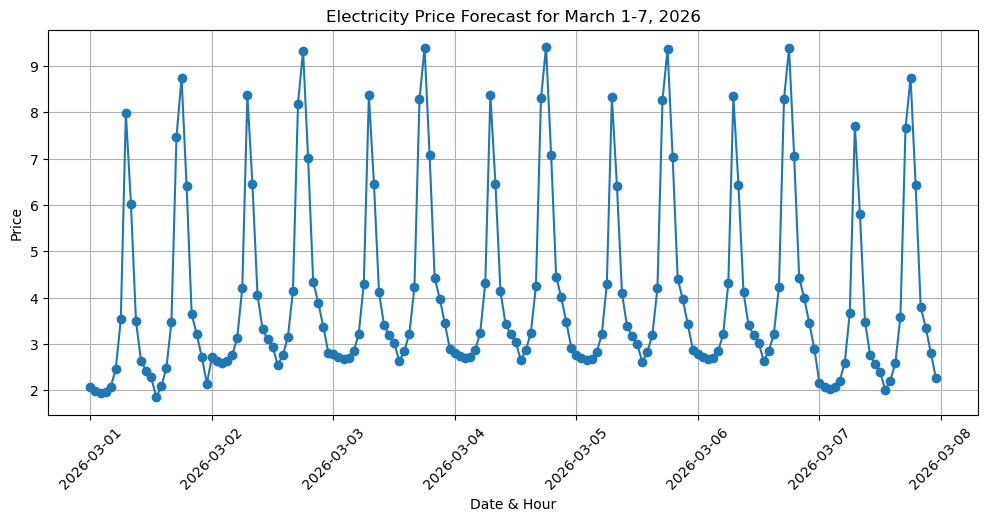

In [22]:
plt.figure(figsize=(12,5))

plt.plot(future_df['timestamp'], future_df['Forecast_Price'], marker='o')

plt.title("Electricity Price Forecast for March 1-7, 2026")
plt.xlabel("Date & Hour")
plt.ylabel("Price")

plt.xticks(rotation=45)
plt.grid(True)
plt.show()

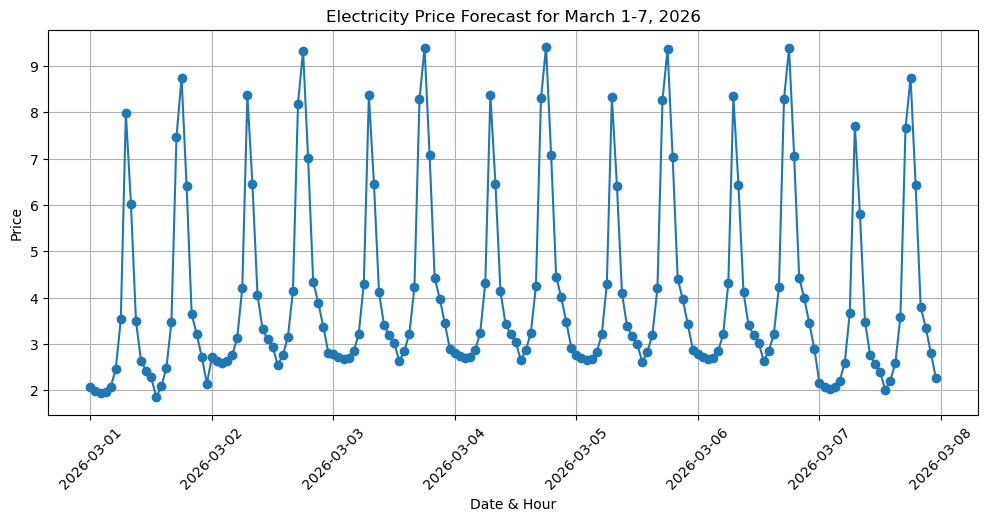

In [23]:
plt.figure(figsize=(12,5))

plt.plot(future_df['timestamp'], future_df['Forecast_Price'], marker='o')

plt.title("Electricity Price Forecast for March 1-7, 2026")
plt.xlabel("Date & Hour")
plt.ylabel("Price")

plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [24]:
future_df['Forecast_Price'].describe()

count    168.000000
mean       4.054697
std        2.041079
min        1.849538
25%        2.714036
50%        3.222492
75%        4.304205
max        9.403892
Name: Forecast_Price, dtype: float64

In [25]:
future_df['Date'] = future_df['timestamp'].dt.date
future_df['Hour_Time'] = future_df['timestamp'].dt.strftime('%I %p').str.lstrip('0')

In [26]:
high_threshold = future_df['Forecast_Price'].quantile(0.75)
medium_threshold = future_df['Forecast_Price'].quantile(0.50)

def sellback_decision(price):
    if price >= high_threshold:
        return "Sell"
    elif price >= medium_threshold:
        return "Sell_Partial"
    else:
        return "Store"

In [27]:
future_df["Forecast_Decision"] = future_df["Forecast_Price"].apply(sellback_decision)
future_df['Date'] = future_df['timestamp'].dt.date
future_df['Hour_Time'] = future_df['timestamp'].dt.strftime('%I %p').str.lstrip('0')
result = future_df[['Date', 'Hour_Time', 'Forecast_Price', 'Forecast_Decision']]
print(result.to_string())

           Date Hour_Time  Forecast_Price Forecast_Decision
0    2026-03-01     12 AM        2.072825             Store
1    2026-03-01      1 AM        1.988432             Store
2    2026-03-01      2 AM        1.948395             Store
3    2026-03-01      3 AM        1.971559             Store
4    2026-03-01      4 AM        2.073048             Store
5    2026-03-01      5 AM        2.448450             Store
6    2026-03-01      6 AM        3.531523      Sell_Partial
7    2026-03-01      7 AM        7.989908              Sell
8    2026-03-01      8 AM        6.030263              Sell
9    2026-03-01      9 AM        3.489098      Sell_Partial
10   2026-03-01     10 AM        2.633490             Store
11   2026-03-01     11 AM        2.420802             Store
12   2026-03-01     12 PM        2.283207             Store
13   2026-03-01      1 PM        1.849538             Store
14   2026-03-01      2 PM        2.087351             Store
15   2026-03-01      3 PM        2.47600